# Numerical Project 2a – Illustration of Itô Formula

This project illustrates the Itô formula using simulations of Brownian motion.

The Itô formula states that for a twice differentiable function \(f\),

$$
f(B_t) - f(B_0) = \int_0^t f'(B_s)dB_s + \frac{1}{2}\int_0^t f''(B_s)ds
$$

We simulate Brownian motion paths and compare both sides of the identity for two functions:

- \(f(x) = x^4\)
- \(f(x) = \sin(x)\)

The simulations use a time discretization of \(0.001\).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Simulation of Brownian Motion

In [2]:
def brownian(interval, step):

    n = int(interval/step)

    B = [0]

    for i in range(n):
        B.append(B[-1] + np.sqrt(step)*np.random.standard_normal())

    return np.array(B)

## Part (a): Case \(f(x)=x^4\)

For \(f(x)=x^4\), we have

$$
f'(x)=4x^3, \quad f''(x)=12x^2
$$

The Itô formula becomes

$$
B_t^4 = \int_0^t 4B_s^3 dB_s + \int_0^t 6B_s^2 ds
$$

which can be written as

$$
B_t^4 - \int_0^t 6B_s^2 ds = \int_0^t 4B_s^3 dB_s
$$

We simulate both sides and compare the resulting paths.

In [3]:
np.random.seed(0)

step = 0.001
T = 1

B = brownian(T,step)

t = np.linspace(0,T,len(B))

### Simulation of the Itô Integral

$$
\int_0^t 4B_s^3 dB_s
$$

In [5]:
Ito = [0]

for i in range(1,len(B)):
    
    increment = 4*(B[i-1]**3)*(B[i]-B[i-1])
    
    Ito.append(Ito[-1] + increment)

Ito = np.array(Ito)

### Simulation of the Riemann Integral

$$
\int_0^t 6B_s^2 ds
$$

In [6]:
Riemann = [0]

for i in range(1,len(B)):
    
    increment = 6*(B[i-1]**2)*step
    
    Riemann.append(Riemann[-1] + increment)

Riemann = np.array(Riemann)

### Process

$$
B_t^4 - \int_0^t 6B_s^2 ds
$$

In [7]:
Left = B**4 - Riemann

### Comparison of both sides

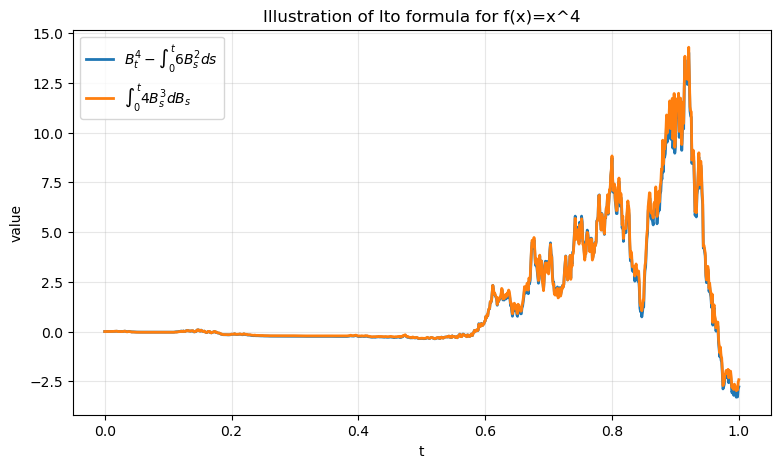

In [10]:
plt.figure(figsize=(9,5))

plt.plot(t,Left,label=r"$B_t^4 - \int_0^t 6B_s^2 ds$",linewidth=2)

plt.plot(t,Ito,label=r"$\int_0^t 4B_s^3 dB_s$",linewidth=2)

plt.xlabel("t")

plt.ylabel("value")

plt.title("Illustration of Ito formula for f(x)=x^4")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Discussion

The two simulated paths are almost identical, which confirms the Itô identity

$$
B_t^4 =
\int_0^t 4B_s^3 dB_s +
\int_0^t 6B_s^2 ds
$$

The small differences between the curves are due to the discretization error in the numerical approximation.

## Part (b): Case \(f(x)=\sin(x)\)

For \(f(x)=\sin(x)\), we have

$$
f'(x)=\cos(x), \qquad f''(x)=-\sin(x)
$$

The Itô formula becomes

$$
\sin(B_t)=\int_0^t \cos(B_s)\,dB_s-\frac12\int_0^t \sin(B_s)\,ds
$$

which can be written as

$$
\sin(B_t)+\frac12\int_0^t \sin(B_s)\,ds
=
\int_0^t \cos(B_s)\,dB_s
$$

We simulate both sides and compare the paths.

In [11]:
np.random.seed(0)

step = 0.001
T = 1

B = brownian(T, step)

t = np.linspace(0, T, len(B))

### Simulation of the Itô integral

$$
\int_0^t \cos(B_s)\,dB_s
$$

In [13]:
Ito2 = [0]

for i in range(1, len(B)):
    
    increment = np.cos(B[i-1]) * (B[i] - B[i-1])
    
    Ito2.append(Ito2[-1] + increment)

Ito2 = np.array(Ito2)

### Simulation of the Riemann integral

$$
\frac12\int_0^t \sin(B_s)\,ds
$$

In [14]:
Riemann2 = [0]

for i in range(1, len(B)):
    
    increment = 0.5 * np.sin(B[i-1]) * step
    
    Riemann2.append(Riemann2[-1] + increment)

Riemann2 = np.array(Riemann2)

### Process

$$
\sin(B_t)+\frac12\int_0^t \sin(B_s)\,ds
$$

In [15]:
Left2 = np.sin(B) + Riemann2

### Comparison of both sides

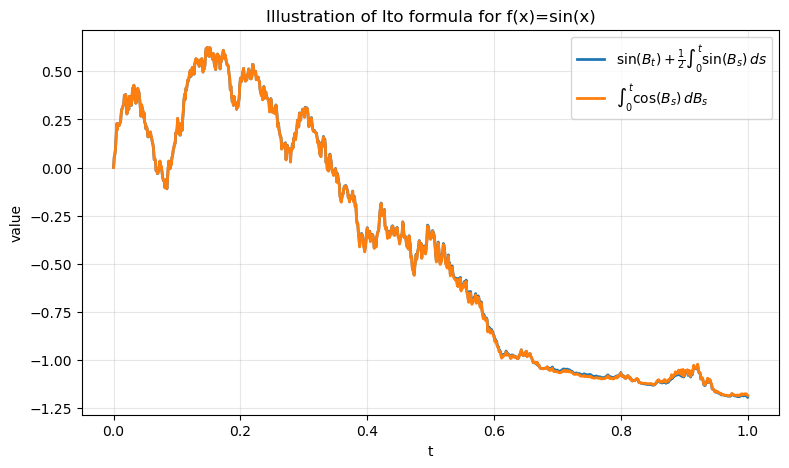

In [19]:
plt.figure(figsize=(9,5))

plt.plot(t, Left2, label=r"$\sin(B_t)+\frac{1}{2}\int_0^t \sin(B_s)\,ds$", linewidth=2)

plt.plot(t, Ito2, label=r"$\int_0^t \cos(B_s)\,dB_s$", linewidth=2)

plt.xlabel("t")
plt.ylabel("value")
plt.title("Illustration of Ito formula for f(x)=sin(x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Discussion

The two simulated paths are almost identical, confirming the Itô identity

$$
\sin(B_t) = \int_0^t \cos(B_s)dB_s - \frac{1}{2}\int_0^t \sin(B_s)ds
$$

The small differences between the curves are due to discretization errors introduced by the numerical approximation of the integrals.